In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Upsampled Species Distribution

## 1. Load Data

In [9]:
df_index = pd.read_csv('../data/train_upsampled_species/species_segment_index.csv')
df_folder = pd.read_csv('../data/train_upsampled_species/FolderCounts.csv')

all_species = df_folder['FolderName'].tolist()  # 234 species names

print(f"Total segments in index: {len(df_index)}")
print(f"Total unique species (from FolderCounts): {len(all_species)}")

Total segments in index: 74385
Total unique species (from FolderCounts): 234


## 2. Count Species Appearances Across All Segments

Each segment's `original_primary_label` may contain multiple species separated by `;`.
Every species listed in a segment counts as one appearance for that species.

In [10]:
# Split multi-label values on ';', strip whitespace, explode to one row per species per segment
exploded = (
    df_index['original_primary_label']
    .str.split(';')
    .explode()
    .str.strip()
)

species_counts = exploded.value_counts()

# Build full distribution for all 234 species (0 count for those not in index)
species_dist_df = pd.DataFrame({'species': all_species})
species_dist_df = species_dist_df.merge(
    species_counts.rename('count').reset_index().rename(columns={'index': 'species', 'original_primary_label': 'species'}),
    on='species',
    how='left'
)
species_dist_df['count'] = species_dist_df['count'].fillna(0).astype(int)
species_dist_df = species_dist_df.sort_values('count', ascending=False).reset_index(drop=True)

print(f"Species with at least 1 segment: {(species_dist_df['count'] > 0).sum()}")
print(f"Species with 0 segments: {(species_dist_df['count'] == 0).sum()}")

Species with at least 1 segment: 234
Species with 0 segments: 0


## 3. Top 5 + Bottom 5 Species Appearances

In [11]:
print("Top 5 Species Appearances (After Upsample):")
print(species_dist_df[['species', 'count']].head(5).to_string(index=False))

print("\nBottom 5 Species Appearances (After Upsample):")
print(species_dist_df[['species', 'count']].tail(5).to_string(index=False))

Top 5 Species Appearances (After Upsample):
species  count
 whtdov   1190
 grekis   1115
 osprey    988
  65380    980
 greyel    940

Bottom 5 Species Appearances (After Upsample):
species  count
 555123     12
 209233      8
  70711      8
  23724      4
  23150      4


## 4. Bar Chart — Upsampled Species Distribution

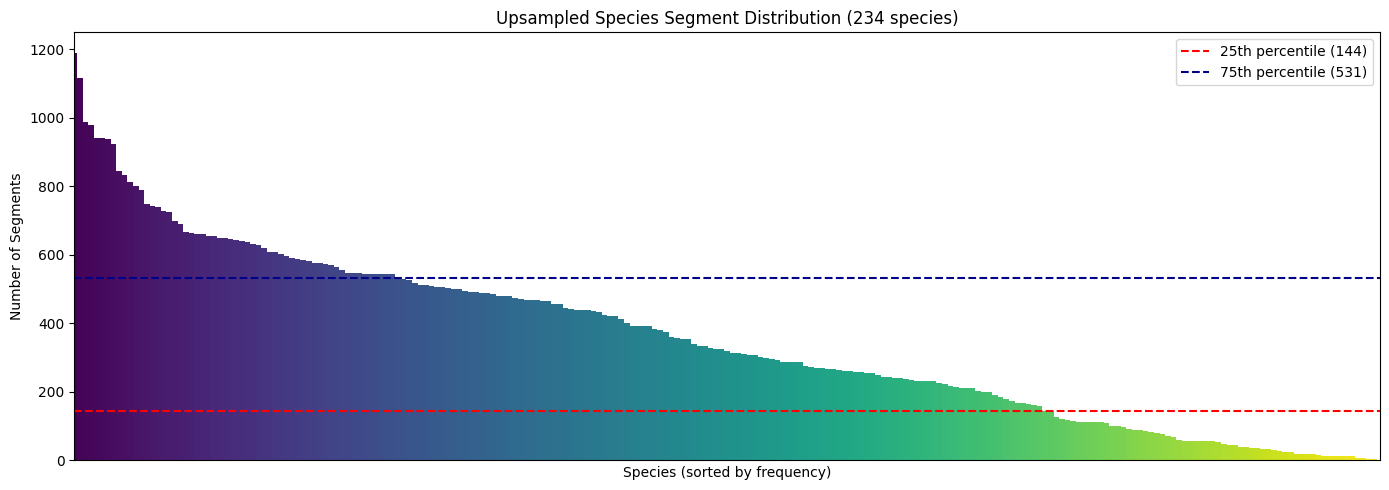

In [14]:
counts = species_dist_df['count'].values

p25 = np.percentile(counts, 25)
p75 = np.percentile(counts, 75)

plt.figure(figsize=(14, 5))
colors = sns.color_palette("viridis", len(counts))

plt.bar(np.arange(len(counts)), counts, color=colors, width=1.0, edgecolor='none')

plt.axhline(y=p25, color='red', linestyle='--', label=f'25th percentile ({p25:.0f})')
plt.axhline(y=p75, color='darkblue', linestyle='--', label=f'75th percentile ({p75:.0f})')

plt.title('Upsampled Species Segment Distribution (234 species)')
plt.ylabel('Number of Segments')
plt.xlabel('Species (sorted by frequency)')
plt.xlim(0, len(counts))
plt.xticks([])
plt.legend()
plt.tight_layout()
plt.show()

## 5. Save Distribution CSV

In [13]:
species_dist_df.to_csv('upsampled_species_distribution.csv', index=False)

print(f"Total species saved: {len(species_dist_df)}")
print("Saved to visualization/upsampled_species_distribution.csv")

Total species saved: 234
Saved to visualization/upsampled_species_distribution.csv
